In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [3]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

In [4]:
sigma = 0.02
N_points = 1000

In [5]:
Mirr = []
chi = []
for i in range(10):
    chii = scipy.stats.uniform.rvs(0, 1, N_points)
    chi = np.append(chi,chii)
    M = norm.rvs(1,sigma,N_points)
    Mirri = M*f(chii)
    Mirr = np.append(Mirr, Mirri)

(array([0.07684338, 0.41336438, 0.80023105, 1.32488584, 1.84954063,
        2.8352557 , 4.51786071, 8.50841686, 5.65991231, 0.51140593]),
 array([0.68971785, 0.72745695, 0.76519605, 0.80293515, 0.84067425,
        0.87841335, 0.91615246, 0.95389156, 0.99163066, 1.02936976,
        1.06710886]),
 <BarContainer object of 10 artists>)

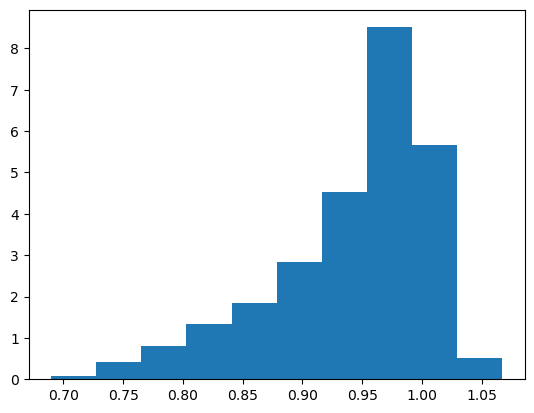

In [6]:
plt.hist(Mirr,density=True)

[]

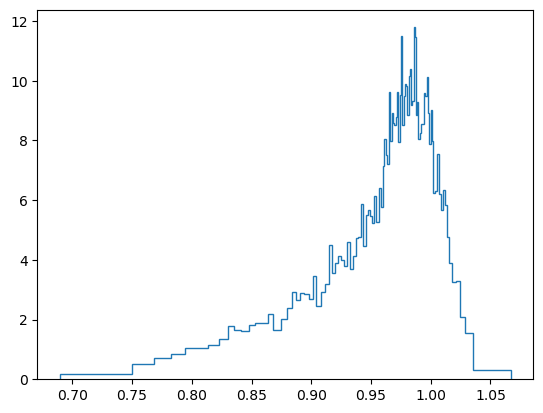

In [7]:
bins100 = np.append(np.sort(Mirr)[::100], np.max(Mirr)) 
plt.hist(Mirr, bins=bins100, density=True, histtype="step") 
plt.plot()

(array([0.03979445, 0.02652964, 0.05305927, 0.10611854, 0.15917782,
        0.26529636, 0.437739  , 0.27856118, 0.42447418, 0.6632409 ,
        0.53059272, 0.82241872, 0.63671127, 0.87547799, 1.14077435,
        0.91527245, 1.28668735, 1.16730399, 1.52545408, 1.72442635,
        1.5387189 , 1.80401526, 2.00298753, 1.96319307, 1.85707453,
        2.5733747 , 2.59990434, 2.89173034, 2.81214143, 3.3029397 ,
        3.91312133, 3.97944542, 4.16515287, 4.97430677, 5.51816431,
        6.03549222, 8.13133347, 9.12619483, 9.59046346, 9.550669  ,
        9.04660592, 7.21606103, 6.14161076, 3.70088424, 2.48052098,
        1.51218926, 0.61018163, 0.31835563, 0.11938336, 0.07958891,
        0.01326482]),
 array([0.68971785, 0.69725659, 0.70479533, 0.71233407, 0.71987281,
        0.72741155, 0.73495028, 0.74248902, 0.75002776, 0.7575665 ,
        0.76510524, 0.77264398, 0.78018272, 0.78772146, 0.7952602 ,
        0.80279894, 0.81033767, 0.81787641, 0.82541515, 0.83295389,
        0.84049263, 0.8480

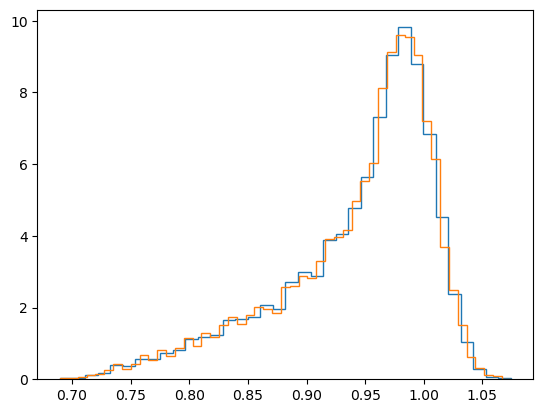

In [8]:
import astropy.visualization.hist
astropy.visualization.hist(Mirr, bins="scott", histtype="step",density=True)
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

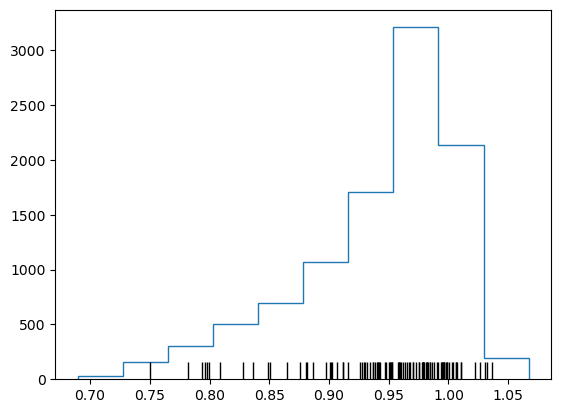

In [9]:
plt.hist(Mirr,histtype="step")
plt.plot(Mirr[:100], 0*Mirr[:100], '|', color='k', markersize=25);

In [10]:
from sklearn.neighbors import KernelDensity

In [11]:
xgrid = np.linspace(Mirr.min(),Mirr.max(),10000)

In [12]:
def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

[]

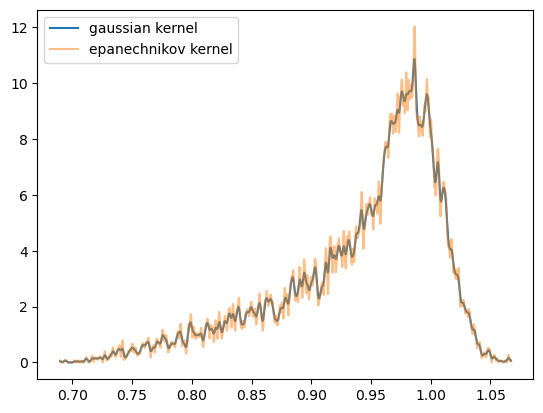

In [13]:
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.001,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 0.5)
plt.legend()
plt.plot()

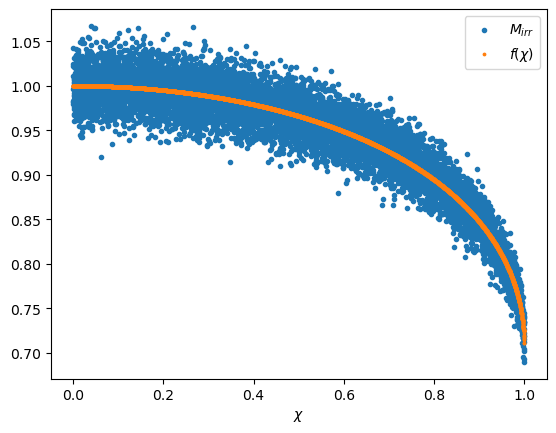

In [14]:
plt.scatter(chi,Mirr,marker='.', label=r'$M_{irr}$')
plt.scatter(chi,f(chi),s=3, label=r'$f(\chi)$')
plt.xlabel(r'$\chi$')
plt.legend()

In [15]:
print(stats.ks_2samp(Mirr,f(chi)))

KstestResult(statistic=0.1584, pvalue=7.573923730106769e-110, statistic_location=0.9999999999946036, statistic_sign=-1)


In [16]:
N_sigma = 30
sigmas= np.logspace(-5,1,N_sigma)
sigmas

array([1.00000000e-05, 1.61026203e-05, 2.59294380e-05, 4.17531894e-05,
       6.72335754e-05, 1.08263673e-04, 1.74332882e-04, 2.80721620e-04,
       4.52035366e-04, 7.27895384e-04, 1.17210230e-03, 1.88739182e-03,
       3.03919538e-03, 4.89390092e-03, 7.88046282e-03, 1.26896100e-02,
       2.04335972e-02, 3.29034456e-02, 5.29831691e-02, 8.53167852e-02,
       1.37382380e-01, 2.21221629e-01, 3.56224789e-01, 5.73615251e-01,
       9.23670857e-01, 1.48735211e+00, 2.39502662e+00, 3.85662042e+00,
       6.21016942e+00, 1.00000000e+01])

/tmp/ipykernel_12426/1844867091.py:10: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])


Text(0.5, 0, '$M_{irr}$')

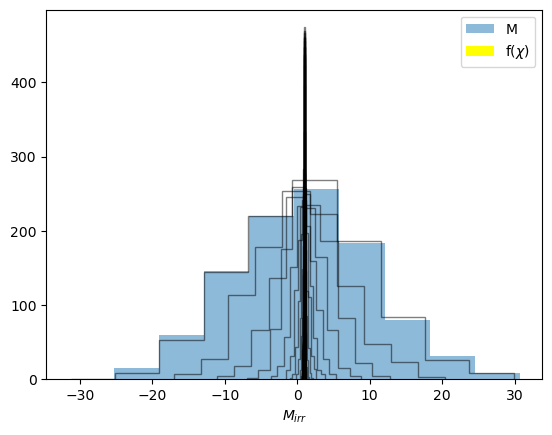

In [17]:
KSs_f = []
KSs_M = []

for i in range(N_sigma):
    chi = scipy.stats.uniform.rvs(0, 1, N_points)
    M = norm.rvs(1,sigmas[i],N_points)
    Mirri = M*f(chi)
    plt.hist(Mirri,histtype="step",color='k',alpha=0.5)
    
    KSs_f = np.append(KSs_f, stats.ks_2samp(Mirri,f(chi))[1])
    KSs_M = np.append(KSs_M, stats.ks_2samp(Mirri,M)[1])

plt.hist(M,alpha=0.5,label='M')
plt.hist(f(chi),alpha=1,color='yellow',label=r'f($\chi$)')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0, 0.5, 'KS M$_{irr}$-f')

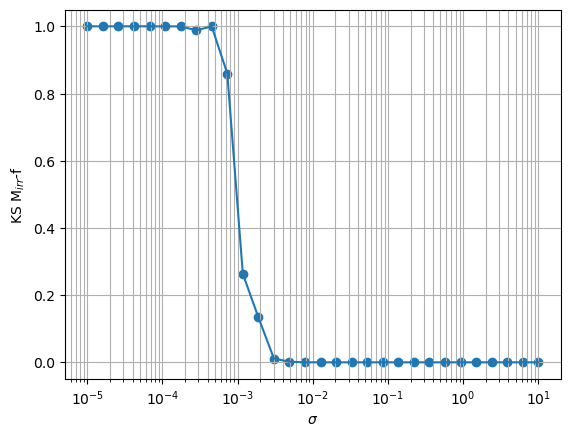

In [18]:
plt.grid(which='both')
plt.plot(sigmas, KSs_f)
plt.scatter(sigmas, KSs_f)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-f')


Text(0, 0.5, 'KS M$_{irr}$-M')

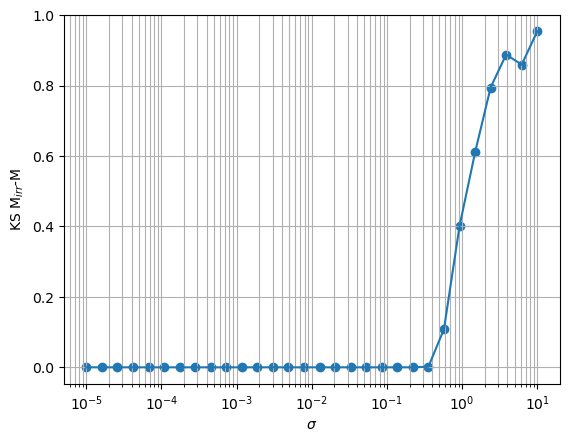

In [19]:
plt.grid(which='both')
plt.plot(sigmas, KSs_M)
plt.scatter(sigmas, KSs_M)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel(r'KS M$_{irr}$-M')

In [ ]:
# Mirr is distributed like f if sigma<<mu and Mirr is distributed like M if mu<<sigma

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
def p_f(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)
def integrand(f,x):
    return ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
def p_Mirr(f,x):
    return [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

N = 10000
x = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

Mirr_from_int = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

In [ ]:
plt.plot(x,Mirr_from_int,label='Exact',c='black',ls=':')
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat,label='epanechnikov kernel',alpha = 1)
PDFtophat = kde_sklearn(Mirr,bandwidth=0.005,kernel="gaussian") 
plt.plot(xgrid,PDFtophat,label='gaussian kernel',alpha = 1)

plt.title('KDE vs. theoretical results')
plt.legend()
plt.plot()